In [3]:
import pandas as pd

# Load the dataset
df = pd.read_csv('/content/netflix_titles.csv')

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Initial Data Exploration (EDA)

In [5]:
# Display the first 5 rows of the DataFrame
print("First 5 rows of the dataset:")
display(df.head())

First 5 rows of the dataset:


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [6]:
# Get a summary of the DataFrame including data types and non-null values
print("\nDataFrame Info:")
df.info()


DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [7]:
# Check for missing values
print("\nMissing values per column:")
display(df.isnull().sum())


Missing values per column:


,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


In [8]:
# Check for duplicate rows
print("\nNumber of duplicate rows:")
display(df.duplicated().sum())


Number of duplicate rows:


np.int64(0)

### Data Cleaning: Handling Missing Values and Feature Engineering

In [9]:
# Impute missing values in 'director', 'cast', 'country' with 'Unknown'
df['director'].fillna('Unknown', inplace=True)
df['cast'].fillna('Unknown', inplace=True)
df['country'].fillna('Unknown', inplace=True)

# Drop rows with missing values in 'date_added', 'rating', 'duration'
df.dropna(subset=['date_added', 'rating', 'duration'], inplace=True)

print("Missing values after handling:")
display(df.isnull().sum())

Missing values after handling:


/tmp/ipykernel_1637/632120596.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['director'].fillna('Unknown', inplace=True)
/tmp/ipykernel_1637/632120596.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try usin

,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,0
release_year,0
rating,0
duration,0


In [10]:
# Convert 'date_added' to datetime
df['date_added'] = pd.to_datetime(df['date_added'])

# Extract year and month from 'date_added'
df['month_added'] = df['date_added'].dt.month
df['year_added'] = df['date_added'].dt.year

print("DataFrame Info after date conversion:")
df.info()

DataFrame Info after date conversion:
<class 'pandas.core.frame.DataFrame'>
Index: 8790 entries, 0 to 8806
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       8790 non-null   object        
 1   type          8790 non-null   object        
 2   title         8790 non-null   object        
 3   director      8790 non-null   object        
 4   cast          8790 non-null   object        
 5   country       8790 non-null   object        
 6   date_added    8790 non-null   datetime64[ns]
 7   release_year  8790 non-null   int64         
 8   rating        8790 non-null   object        
 9   duration      8790 non-null   object        
 10  listed_in     8790 non-null   object        
 11  description   8790 non-null   object        
 12  month_added   8790 non-null   int32         
 13  year_added    8790 non-null   int32         
dtypes: datetime64[ns](1), int32(2), int64(1), object(10)
me

In [11]:
# Process 'duration' column
# Separate 'duration' into 'duration_minutes' for Movies and 'num_seasons' for TV Shows

df['duration_minutes'] = df['duration'].apply(lambda x: int(x.split(' ')[0]) if 'min' in x else 0)
df['num_seasons'] = df['duration'].apply(lambda x: int(x.split(' ')[0]) if 'Season' in x else 0)

# Drop the original 'duration' column as it has been processed into new features
df.drop('duration', axis=1, inplace=True)

print("\nFirst 5 rows with new duration features:")
display(df[['type', 'duration_minutes', 'num_seasons']].head())


First 5 rows with new duration features:


,type,duration_minutes,num_seasons
0,Movie,90,0
1,TV Show,0,2
2,TV Show,0,1
3,TV Show,0,1
4,TV Show,0,2


### Exploratory Data Analysis: Visualizations

/tmp/ipykernel_1637/1085275361.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='type', data=df, palette='viridis')


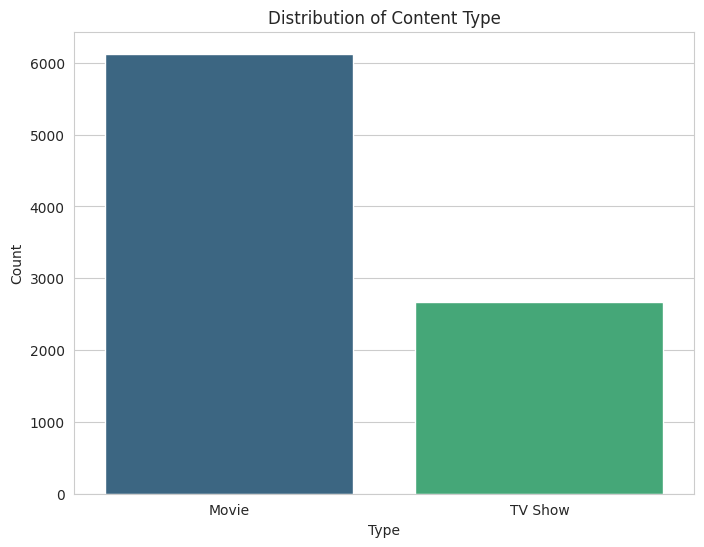

/tmp/ipykernel_1637/1085275361.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='country', data=df, order=df['country'].value_counts().index[:10], palette='magma')


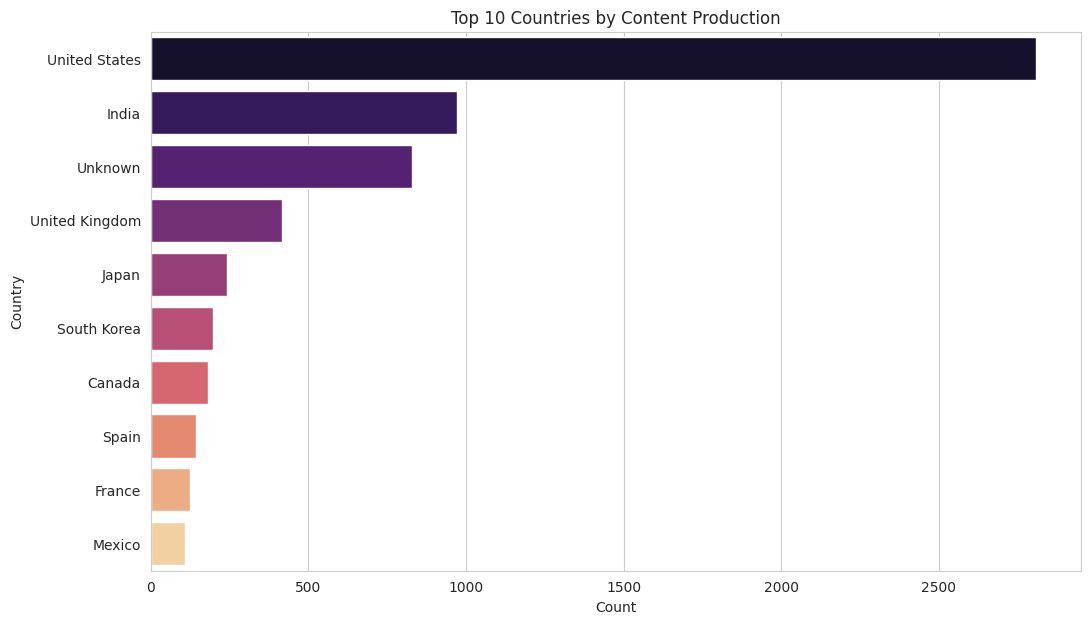

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

# Distribution of Content Type (Movie vs TV Show)
plt.figure(figsize=(8, 6))
sns.countplot(x='type', data=df, palette='viridis')
plt.title('Distribution of Content Type')
plt.xlabel('Type')
plt.ylabel('Count')
plt.show()

# Top 10 Countries by Content Production
plt.figure(figsize=(12, 7))
sns.countplot(y='country', data=df, order=df['country'].value_counts().index[:10], palette='magma')
plt.title('Top 10 Countries by Content Production')
plt.xlabel('Count')
plt.ylabel('Country')
plt.show()

/tmp/ipykernel_1637/443115750.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='director', data=df[df['director'] != 'Unknown'], order=df[df['director'] != 'Unknown']['director'].value_counts().index[:10], palette='cubehelix')


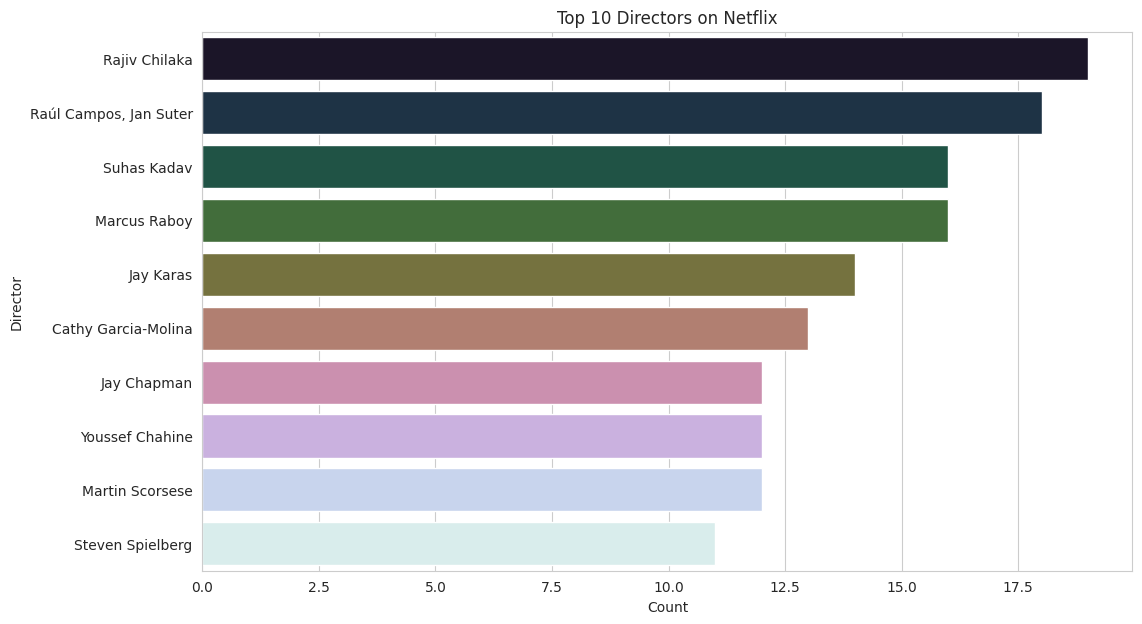

/tmp/ipykernel_1637/443115750.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=genres, order=genres.value_counts().index[:10], palette='rocket')


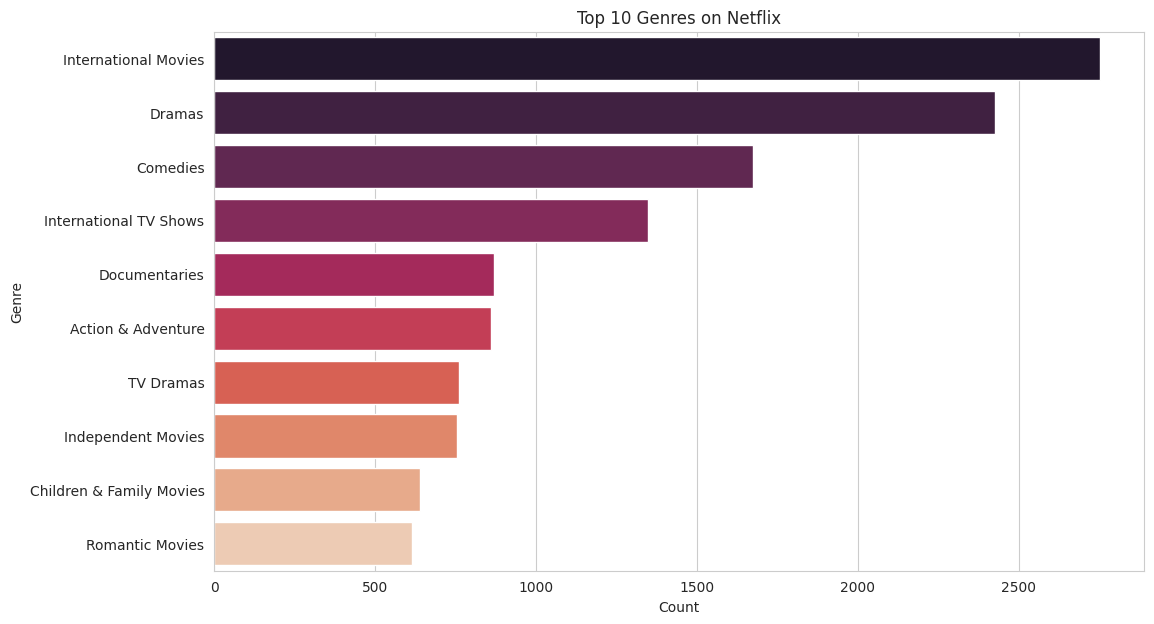

In [13]:
# Top 10 Directors (excluding 'Unknown')
plt.figure(figsize=(12, 7))
sns.countplot(y='director', data=df[df['director'] != 'Unknown'], order=df[df['director'] != 'Unknown']['director'].value_counts().index[:10], palette='cubehelix')
plt.title('Top 10 Directors on Netflix')
plt.xlabel('Count')
plt.ylabel('Director')
plt.show()

# Top 10 Genres (listed_in)
# Since 'listed_in' can have multiple genres, we'll split and count
genres = df['listed_in'].str.split(', ', expand=True).stack()
plt.figure(figsize=(12, 7))
sns.countplot(y=genres, order=genres.value_counts().index[:10], palette='rocket')
plt.title('Top 10 Genres on Netflix')
plt.xlabel('Count')
plt.ylabel('Genre')
plt.show()

/tmp/ipykernel_1637/847841719.py:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(df['release_year'], bins=30, kde=True, palette='coolwarm')


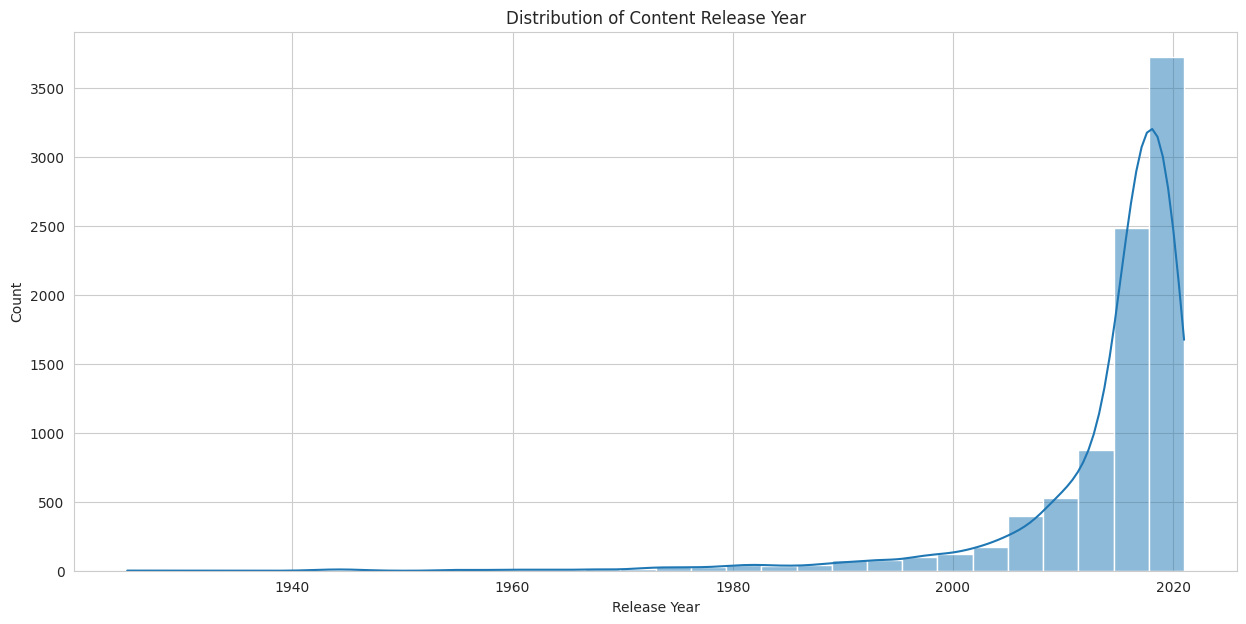

/tmp/ipykernel_1637/847841719.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='rating', data=df, order=df['rating'].value_counts().index, palette='crest')


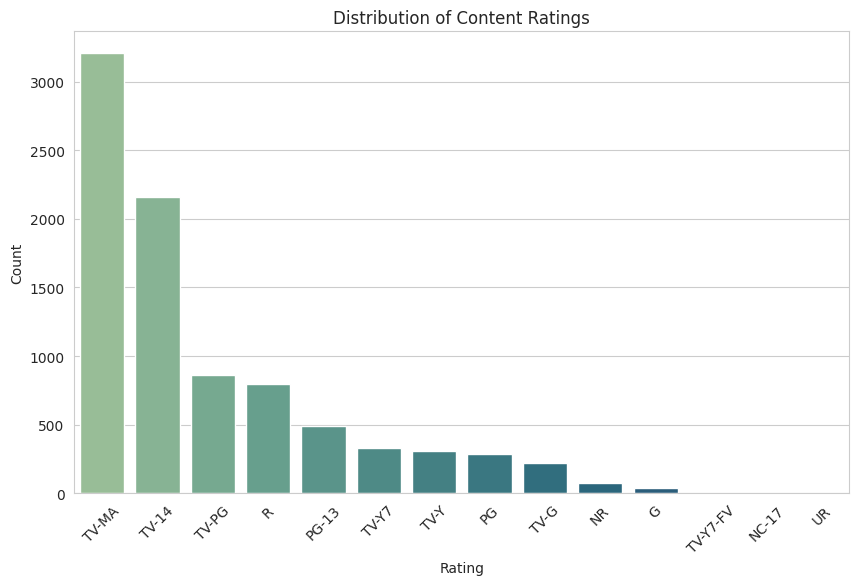

In [14]:
# Distribution of Release Year
plt.figure(figsize=(15, 7))
sns.histplot(df['release_year'], bins=30, kde=True, palette='coolwarm')
plt.title('Distribution of Content Release Year')
plt.xlabel('Release Year')
plt.ylabel('Count')
plt.show()

# Distribution of Ratings
plt.figure(figsize=(10, 6))
sns.countplot(x='rating', data=df, order=df['rating'].value_counts().index, palette='crest')
plt.title('Distribution of Content Ratings')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

### Preprocessing: Label Encoding Categorical Features

In [15]:
from sklearn.preprocessing import LabelEncoder

# Make a copy of the DataFrame to avoid modifying the original during encoding for potential future use
df_encoded = df.copy()

# Identify categorical columns for Label Encoding
# Exclude 'show_id', 'title', 'description' as they are not suitable for direct label encoding
# 'date_added' has been converted and used for 'month_added' and 'year_added'
categorical_cols = ['type', 'director', 'cast', 'country', 'rating', 'listed_in']

# Apply Label Encoding to each categorical column
label_encoders = {}
for col in categorical_cols:
    label_encoders[col] = LabelEncoder()
    df_encoded[col] = label_encoders[col].fit_transform(df_encoded[col])

print("DataFrame after Label Encoding:")
display(df_encoded.head())

print("\nInfo of the encoded DataFrame:")
df_encoded.info()

DataFrame after Label Encoding:


,show_id,type,title,director,cast,country,date_added,release_year,rating,listed_in,description,month_added,year_added,duration_minutes,num_seasons
0,s1,0,Dick Johnson Is Dead,2294,7233,603,2021-09-25,2020,4,273,"As her father nears the end of his life, filmm...",9,2021,90,0
1,s2,1,Blood & Water,4301,408,426,2021-09-24,2021,8,413,"After crossing paths at a party, a Cape Town t...",9,2021,0,2
2,s3,1,Ganglands,2104,6283,736,2021-09-24,2021,8,241,To protect his family from a powerful drug lor...,9,2021,0,1
3,s4,1,Jailbirds New Orleans,4301,7233,736,2021-09-24,2021,8,296,"Feuds, flirtations and toilet talk go down amo...",9,2021,0,1
4,s5,1,Kota Factory,4301,4801,251,2021-09-24,2021,8,392,In a city of coaching centers known to train I...,9,2021,0,2



Info of the encoded DataFrame:
<class 'pandas.core.frame.DataFrame'>
Index: 8790 entries, 0 to 8806
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   show_id           8790 non-null   object        
 1   type              8790 non-null   int64         
 2   title             8790 non-null   object        
 3   director          8790 non-null   int64         
 4   cast              8790 non-null   int64         
 5   country           8790 non-null   int64         
 6   date_added        8790 non-null   datetime64[ns]
 7   release_year      8790 non-null   int64         
 8   rating            8790 non-null   int64         
 9   listed_in         8790 non-null   int64         
 10  description       8790 non-null   object        
 11  month_added       8790 non-null   int32         
 12  year_added        8790 non-null   int32         
 13  duration_minutes  8790 non-null   int64         
 1

In [16]:
# Define features (X) and target (y)
X = df_encoded.drop(columns=['show_id', 'title', 'description', 'date_added', 'type'])
y = df_encoded['type']

print("Features (X) and Target (y) defined.")
print(f"X shape: {X.shape}, y shape: {y.shape}")

Features (X) and Target (y) defined.
X shape: (8790, 10), y shape: (8790,)


In [17]:
from sklearn.model_selection import train_test_split

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data split into training and testing sets.")
print(f"X_train shape: {X_train.shape}, X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}, y_test shape: {y_test.shape}")

Data split into training and testing sets.
X_train shape: (7032, 10), X_test shape: (1758, 10)
y_train shape: (7032,), y_test shape: (1758,)


Now that the data is properly split, please **re-run the following cells in order** to ensure the model and related variables are correctly defined:

1.  **Model Training and Evaluation** (cell `e2bf87e6`)
2.  **Hyperparameter Tuning** (cell `76fb188c`)
3.  **Save the Model and Encoders** (cell `64d8d22a`)

### Preparing Data for Machine Learning: Feature Selection and Data Splitting

### Machine Learning Model Training and Evaluation

In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Initialize a dictionary to store models and their names
models = {
    'Logistic Regression': LogisticRegression(random_state=42, solver='liblinear'),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier()
}

results = pd.DataFrame(columns=['Model', 'Accuracy', 'Precision', 'Recall', 'F1-Score'])

print("Training and evaluating models...")

for name, model in models.items():
    # Train the model
    model.fit(X_train, y_train)

    # Make predictions on the test set
    y_pred = model.predict(X_test)

    # Calculate evaluation metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

    # Store results
    results.loc[len(results)] = [name, accuracy, precision, recall, f1]

    print(f"\n--- {name} ---")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print("Classification Report:")
    print(classification_report(y_test, y_pred, zero_division=0))

print("\n--- Model Comparison ---")
display(results.sort_values(by='F1-Score', ascending=False))

Training and evaluating models...

--- Logistic Regression ---
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1-Score: 1.0000
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1227
           1       1.00      1.00      1.00       531

    accuracy                           1.00      1758
   macro avg       1.00      1.00      1.00      1758
weighted avg       1.00      1.00      1.00      1758


--- Decision Tree ---
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1-Score: 1.0000
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1227
           1       1.00      1.00      1.00       531

    accuracy                           1.00      1758
   macro avg       1.00      1.00      1.00      1758
weighted avg       1.00      1.00      1.00      1758


--- Random Forest ---
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1-Scor

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,1.000000,1.000000,1.000000,1.000000
1,Decision Tree,1.000000,1.000000,1.000000,1.000000
2,Random Forest,1.000000,1.000000,1.000000,1.000000
3,Gradient Boosting,1.000000,1.000000,1.000000,1.000000
4,K-Nearest Neighbors,0.936291,0.936518,0.936291,0.936392


### Hyperparameter Tuning: Random Forest Classifier

In [19]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Define the parameter grid for Random Forest Classifier
param_grid = {
    'n_estimators': [100, 200, 300],  # Number of trees in the forest
    'max_depth': [10, 20, 30, None],  # Maximum depth of the tree
    'min_samples_split': [2, 5, 10], # Minimum number of samples required to split an internal node
    'min_samples_leaf': [1, 2, 4],   # Minimum number of samples required to be at a leaf node
    'criterion': ['gini', 'entropy'] # Function to measure the quality of a split
}

# Initialize the Random Forest Classifier
rf_model = RandomForestClassifier(random_state=42)

# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=rf_model, param_grid=param_grid,
                           cv=3, n_jobs=-1, verbose=2, scoring='f1_weighted')

print("Starting Hyperparameter Tuning for Random Forest Classifier...")

# Fit GridSearchCV to the training data
grid_search.fit(X_train, y_train)

print("Hyperparameter Tuning complete.")

# Get the best parameters and best score
best_params = grid_search.best_params_
best_score = grid_search.best_score_

print(f"\nBest Hyperparameters: {best_params}")
print(f"Best F1-Score (weighted) on validation set: {best_score:.4f}")

# Get the best model
best_rf_model = grid_search.best_estimator_

# Evaluate the best model on the test set
y_pred_tuned = best_rf_model.predict(X_test)
accuracy_tuned = accuracy_score(y_test, y_pred_tuned)
precision_tuned = precision_score(y_test, y_pred_tuned, average='weighted', zero_division=0)
recall_tuned = recall_score(y_test, y_pred_tuned, average='weighted', zero_division=0)
f1_tuned = f1_score(y_test, y_pred_tuned, average='weighted', zero_division=0)

print(f"\n--- Tuned Random Forest Model Performance on Test Set ---")
print(f"Accuracy: {accuracy_tuned:.4f}")
print(f"Precision: {precision_tuned:.4f}")
print(f"Recall: {recall_tuned:.4f}")
print(f"F1-Score: {f1_tuned:.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred_tuned, zero_division=0))

Starting Hyperparameter Tuning for Random Forest Classifier...
Fitting 3 folds for each of 216 candidates, totalling 648 fits
Hyperparameter Tuning complete.

Best Hyperparameters: {'criterion': 'gini', 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best F1-Score (weighted) on validation set: 1.0000

--- Tuned Random Forest Model Performance on Test Set ---
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1-Score: 1.0000
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1227
           1       1.00      1.00      1.00       531

    accuracy                           1.00      1758
   macro avg       1.00      1.00      1.00      1758
weighted avg       1.00      1.00      1.00      1758



In [20]:
import joblib

# Save the best Random Forest model
joblib.dump(best_rf_model, 'best_rf_model.pkl')

# Save the label encoders dictionary
joblib.dump(label_encoders, 'label_encoders.pkl')

# Save the feature column names to maintain order during prediction
joblib.dump(X_train.columns.tolist(), 'feature_columns.pkl')

print("Model, label encoders, and feature columns saved successfully.")

Model, label encoders, and feature columns saved successfully.


### Web Application Setup (Flask)

Now, let's create a simple Flask web application. We'll set up `app.py` for the backend logic and `templates/index.html` for the user interface to input new data and `templates/result.html` to display the prediction. First, we need to create a `templates` directory.

In [21]:
import os

# Create the templates directory if it doesn't exist
if not os.path.exists('templates'):
    os.makedirs('templates')
    print("Created 'templates' directory.")
else:
    print("'templates' directory already exists.")

Created 'templates' directory.


In [22]:
%%writefile app.py
from flask import Flask, request, render_template
import joblib
import pandas as pd
import numpy as np

app = Flask(__name__)

# Load the trained model, label encoders, and feature columns
best_rf_model = joblib.load('best_rf_model.pkl')
label_encoders = joblib.load('label_encoders.pkl')
feature_columns = joblib.load('feature_columns.pkl')

# Define the categorical columns that were encoded
categorical_cols = ['type', 'director', 'cast', 'country', 'rating', 'listed_in']
# Exclude 'type' as it is the target variable for prediction
categorical_cols_for_input = [col for col in categorical_cols if col != 'type']

@app.route('/')
def index():
    return render_template('index.html')

@app.route('/predict', methods=['POST'])
def predict():
    # Get form data
    data = {
        'director': request.form['director'],
        'cast': request.form['cast'],
        'country': request.form['country'],
        'release_year': int(request.form['release_year']),
        'rating': request.form['rating'],
        'listed_in': request.form['listed_in'],
        'month_added': int(request.form['month_added']),
        'year_added': int(request.form['year_added']),
        'duration_minutes': int(request.form['duration_minutes']),
        'num_seasons': int(request.form['num_seasons'])
    }

    # Create a DataFrame for the new data point
    new_df = pd.DataFrame([data])

    # Apply the same label encoding transformations
    for col in categorical_cols_for_input:
        if col in new_df.columns and col in label_encoders:
            try:
                new_df[col] = label_encoders[col].transform(new_df[col])
            except ValueError:
                # Handle unseen labels: assign a default value (e.g., 0 for 'Unknown' or an average)
                # For simplicity, we assign 0, which corresponds to 'Unknown' in most of our encoders
                # A more robust solution might involve mapping to a specific 'unseen' category or using a different encoding strategy
                new_df[col] = 0
                print(f"Warning: Unseen label for column '{col}' encountered. Assigned 0.")

    # Ensure the columns are in the same order as the training data
    new_df = new_df[feature_columns]

    # Predict using the best model
    prediction_encoded = best_rf_model.predict(new_df)

    # Inverse transform the prediction to get the original label
    predicted_type = label_encoders['type'].inverse_transform(prediction_encoded)

    return render_template('result.html', prediction=predicted_type[0])

if __name__ == '__main__':
    # You can run this directly in a Colab environment or save as app.py and run locally.
    # In Colab, you might need to use ngrok for external access if running outside localtunnel.
    # For local execution, run `python app.py` in your terminal.
    app.run(host='0.0.0.0', port=5000)

Overwriting app.py


In [23]:
%%writefile templates/index.html
<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <title>Netflix Content Type Predictor</title>
    <style>
        body { font-family: Arial, sans-serif; margin: 20px; background-color: #f4f4f4; }
        .container { max-width: 600px; margin: auto; background: white; padding: 20px; border-radius: 8px; box-shadow: 0 0 10px rgba(0,0,0,0.1); }
        h1 { text-align: center; color: #333; }
        form div { margin-bottom: 15px; }
        label { display: block; margin-bottom: 5px; font-weight: bold; }
        input[type="text"], input[type="number"] { width: calc(100% - 22px); padding: 10px; border: 1px solid #ddd; border-radius: 4px; }
        button { background-color: #e50914; color: white; padding: 10px 15px; border: none; border-radius: 4px; cursor: pointer; font-size: 16px; width: 100%; }
        button:hover { background-color: #f40612; }
    </style>
</head>
<body>
    <div class="container">
        <h1>Predict Netflix Content Type</h1>
        <form action="/predict" method="post">
            <div>
                <label for="director">Director:</label>
                <input type="text" id="director" name="director" value="Marcus Raboy" required>
            </div>
            <div>
                <label for="cast">Cast (comma-separated):</label>
                <input type="text" id="cast" name="cast" value="Adam Sandler" required>
            </div>
            <div>
                <label for="country">Country:</label>
                <input type="text" id="country" name="country" value="United States" required>
            </div>
            <div>
                <label for="release_year">Release Year:</label>
                <input type="number" id="release_year" name="release_year" value="2023" required>
            </div>
            <div>
                <label for="rating">Rating (e.g., TV-MA, PG-13):</label>
                <input type="text" id="rating" name="rating" value="TV-MA" required>
            </div>
            <div>
                <label for="listed_in">Listed In (comma-separated genres):</label>
                <input type="text" id="listed_in" name="listed_in" value="Comedies, Dramas" required>
            </div>
            <div>
                <label for="month_added">Month Added (1-12):</label>
                <input type="number" id="month_added" name="month_added" value="10" required>
            </div>
            <div>
                <label for="year_added">Year Added:</label>
                <input type="number" id="year_added" name="year_added" value="2023" required>
            </div>
            <div>
                <label for="duration_minutes">Duration (minutes for Movies):</label>
                <input type="number" id="duration_minutes" name="duration_minutes" value="120" required>
            </div>
            <div>
                <label for="num_seasons">Number of Seasons (for TV Shows):</label>
                <input type="number" id="num_seasons" name="num_seasons" value="0" required>
            </div>
            <button type="submit">Predict Content Type</button>
        </form>
    </div>
</body>
</html>

Writing templates/index.html


In [24]:
%%writefile templates/result.html
<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <title>Prediction Result</title>
    <style>
        body { font-family: Arial, sans-serif; margin: 20px; background-color: #f4f4f4; }
        .container { max-width: 600px; margin: auto; background: white; padding: 20px; border-radius: 8px; box-shadow: 0 0 10px rgba(0,0,0,0.1); }
        h1 { text-align: center; color: #333; }
        p { text-align: center; font-size: 1.2em; }
        .back-button { display: block; width: 150px; margin: 20px auto; padding: 10px 15px; background-color: #e50914; color: white; text-align: center; text-decoration: none; border-radius: 4px; }
        .back-button:hover { background-color: #f40612; }
    </style>
</head>
<body>
    <div class="container">
        <h1>Prediction Result</h1>
        <p>The predicted content type is: <strong>{{ prediction }}</strong></p>
        <a href="/" class="back-button">Go Back</a>
    </div>
</body>
</html>

Writing templates/result.html


### How to Run the Local Host Application

To run this Flask application locally, follow these steps:

1.  **Run all the previous code cells** in this notebook to ensure the model (`best_rf_model.pkl`), label encoders (`label_encoders.pkl`), feature columns (`feature_columns.pkl`), `app.py`, and the `templates` directory with `index.html` and `result.html` are created in your Colab environment.

2.  **Install Flask (if not already installed):**
    ```bash
    !pip install Flask
    ```

3.  **Run the `app.py` script:**
    You can run `app.py` directly from a new code cell in Colab:

    ```python
    !python app.py
    ```

    Alternatively, if you download `app.py` and the `templates` folder to your local machine, navigate to the directory in your terminal and run:

    ```bash
    python app.py
    ```

4.  **Access the application:**

    *   **In Colab:** When you run `!python app.py`, Flask will start on `http://0.0.0.0:5000`. Colab usually provides a local tunnel link (like `https://<random-id>.ngrok.io` or `http://localhost:5000` with a clickable link) in the output. Look for a message like `* Running on http://0.0.0.0:5000/`. You can then click the provided external link to access your app.
    *   **Locally:** Open your web browser and go to `http://127.0.0.1:5000/` or `http://localhost:5000/`.

You should now see the input form. Enter the details for a new content item, and click "Predict Content Type" to get the prediction from your trained model!

### Prediction for New Data

In [25]:
import numpy as np

# Create a sample new data point (replace with actual new data if available)
# The features must match the columns used for training (X_train.columns)
# Example: director, cast, country, release_year, rating, listed_in, month_added, year_added, duration_minutes, num_seasons
# We'll use values that are somewhat representative or for demonstration.
# Note: For accurate prediction, the new data's categorical features should be transformed using the *same* LabelEncoders used during training.
# For simplicity, we will manually encode some common values, but for a production system, a robust pipeline would be needed.

# Re-using the `label_encoders` dictionary from earlier steps

new_data = {
    'director': 'Marcus Raboy', # A known director
    'cast': 'Adam Sandler', # A known cast member
    'country': 'United States', # A known country
    'release_year': 2023,
    'rating': 'TV-MA', # A known rating
    'listed_in': 'Comedies, Dramas', # A known genre combination
    'month_added': 10,
    'year_added': 2023,
    'duration_minutes': 120,
    'num_seasons': 0 # For a movie
}

# Create a DataFrame for the new data point
new_df = pd.DataFrame([new_data])

# Apply the same label encoding transformations
# Ensure all categorical_cols used in training are present in new_df and correctly encoded
for col in categorical_cols:
    if col in new_df.columns and col in label_encoders:
        # Handle unseen labels in production by either ignoring, mapping to a default, or raising an error
        # For this example, we'll try to transform, but it might fail if a new label is truly unseen and not handled.
        try:
            new_df[col] = label_encoders[col].transform(new_df[col])
        except ValueError as e:
            print(f"Warning: Could not transform '{new_df[col].iloc[0]}' in column '{col}'. Error: {e}")
            # As a fallback, use the mode of the original training data for that column or a default value like 0 or -1
            new_df[col] = 0 # Or some other default value

# Ensure the columns are in the same order as X_train
new_df = new_df[X_train.columns]

print("Preprocessed new data point:")
display(new_df)

# Predict using the best model
prediction_encoded = best_rf_model.predict(new_df)

# Inverse transform the prediction to get the original label
# We need the label encoder for the 'type' column
predicted_type = label_encoders['type'].inverse_transform(prediction_encoded)

print(f"\nPredicted type for the new content: {predicted_type[0]}")

Preprocessed new data point:


,director,cast,country,release_year,rating,listed_in,month_added,year_added,duration_minutes,num_seasons
0,2596,89,603,2023,8,196,10,2023,120,0



Predicted type for the new content: Movie


### Save and Share Notebook

To save your work as an `.ipynb` file (e.g., 'Your_Name.ipynb') and share it via Google Drive, please follow these steps:

1.  **Rename the Notebook:**
    *   Go to `File` > `Rename` in the Colab menu bar.
    *   Enter your desired filename, e.g., `John_Doe.ipynb`, and press Enter.

2.  **Download the Notebook:**
    *   Go to `File` > `Download` > `Download .ipynb`.
    *   This will save the notebook to your local computer.

3.  **Upload to Google Drive:**
    *   Go to your Google Drive (`drive.google.com`).
    *   Click `+ New` on the left sidebar.
    *   Select `File upload`.
    *   Navigate to where you saved the `.ipynb` file on your computer and upload it.

4.  **Share the Link (with Drive Access):**
    *   Once the file is uploaded to Google Drive, locate it.
    *   Right-click on the file and select `Share`.
    *   In the sharing dialog:
        *   Under "General access", change `Restricted` to `Anyone with the link`.
        *   Ensure the role is set to `Viewer` (or `Commenter` if interaction is needed, but `Viewer` is usually sufficient for sharing results).
        *   Click `Copy link`.
        *   Click `Done`.

5.  **Provide the Shared Link:**
    *   Paste the copied link here in our chat or wherever requested.

In [26]:
# The final input columns for X are now printed in cell 913cb618 after data splitting.

In [27]:
import sklearn; print(sklearn.__version__)

1.6.1
